Showing da black hole with visible rays and intensity...


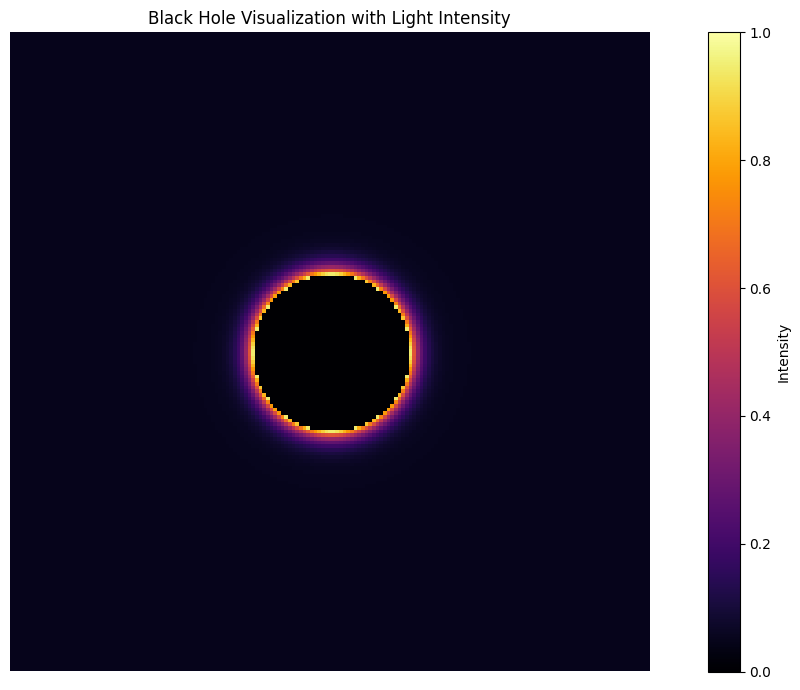

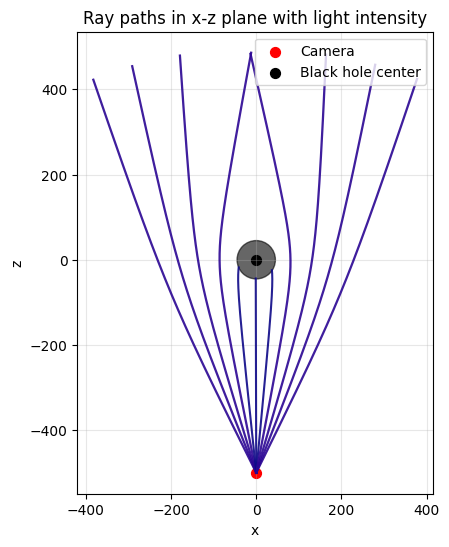

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import constants

# 175x175 pixels til visualisering og udregninger.
width = 175
height = 175

# Simpelt sort hul. Pixels bliver mørke når de er tæt på midten.
Event_horizon = 45.0

# Position af sort hul og "kamera"
kamera_pos = np.array([0.0, 0.0, -500.0])
black_hole_pos = np.array([0.0, 0.0, 0.0])

# Gem baggrund så den kun skal laves en gang
star_directions = None
image_plane_distance = 100.0
scale = 50.0
bh_mass = 15.0
dt = 1.0
max_steps = 1000

def generate_star_directions():
    global star_directions
    if star_directions is not None:
        return
    num_stars = 320
    star_theta = np.random.uniform(0, 2*np.pi, num_stars)
    star_phi = np.random.uniform(0, np.pi, num_stars)
    star_directions = np.array([
        np.sin(star_phi) * np.cos(star_theta),
        np.sin(star_phi) * np.sin(star_theta),
        np.cos(star_phi)
    ]).T


def trace_ray(x, y, record_path=False):
    generate_star_directions()
    px = (x / width * 2 - 1) * scale
    py = (y / height * 2 - 1) * scale
    image_point = kamera_pos + np.array([px, py, image_plane_distance])
    ray_dir = image_point - kamera_pos
    ray_dir = ray_dir / np.linalg.norm(ray_dir)
    ray_pos = kamera_pos.copy()
    path = [ray_pos.copy()] if record_path else None
    min_distance = np.inf

    for _ in range(max_steps):
        diff = black_hole_pos - ray_pos
        distance = np.linalg.norm(diff)
        min_distance = min(min_distance, distance)
        if distance < Event_horizon:
            if record_path:
                path.append(ray_pos.copy())
                return 0.0, np.array(path)
            return 0.0

        if distance > 0.1:
            direction_to_bh = diff / distance
            gravity_strength = bh_mass / distance**2
            acceleration = direction_to_bh * gravity_strength * dt
            ray_dir += acceleration
            ray_dir /= np.linalg.norm(ray_dir)

        ray_pos += ray_dir * dt
        if record_path:
            path.append(ray_pos.copy())

        if np.linalg.norm(ray_pos) > 1000:
            max_dot = np.max(np.dot(star_directions, ray_dir))
            star_intensity = 1.0 if max_dot > 0.999 else 0.05
            glow = np.exp(-0.15 * max(0.0, min_distance - Event_horizon))
            intensity = max(star_intensity, 0.05 + 0.9 * glow)
            if record_path:
                return intensity, np.array(path)
            return intensity

    glow = np.exp(-0.15 * max(0.0, min_distance - Event_horizon))
    intensity = 0.05 + 0.9 * glow
    if record_path:
        return intensity, np.array(path)
    return intensity


def render(num_samples=30625):
    image = np.full((height, width), 0.02, dtype=float)
    center_y, center_x = height // 2, width // 2
    max_trace_radius = Event_horizon * 3.0

#loader kun nogen pixels så den loader meget hurtigere
    y_coords, x_coords = np.where(
        np.hypot(np.arange(height)[:, None] - center_y,
                 np.arange(width)[None, :] - center_x) <= max_trace_radius
    )
    num_samples = min(num_samples, len(x_coords))
    sample_indices = np.random.choice(len(x_coords), size=num_samples, replace=False)

    for idx in sample_indices:
        y = y_coords[idx]
        x = x_coords[idx]
        image[y, x] = trace_ray(x, y)
    return image


def sample_ray_paths():
    sample_x = np.linspace(0, width - 1, 11, dtype=int)
    sample_y = np.full_like(sample_x, height // 2)
    paths = []
    for x, y in zip(sample_x, sample_y):
        intensity, path = trace_ray(x, y, record_path=True)
        paths.append((path, intensity))
    return paths

# da black hole
# Vi vil sætte det sorte hul ved koordinaterne (0,0,0) og kameraet ved (0,0,-500) så vi kigger på det sorte hul

if __name__ == "__main__":
    print("Showing da black hole with visible rays and intensity...")
    image = render()
    ray_paths = sample_ray_paths()

    plt.figure(figsize=(12, 7))
    plt.imshow(image, cmap='inferno', vmin=0, vmax=1)
    plt.title("Black Hole Visualization with Light Intensity")
    plt.axis('off')
    plt.colorbar(label='Intensity')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    for path, intensity in ray_paths:
        color = plt.cm.plasma(np.clip(intensity, 0, 1))
        linewidth = 1.5 + 2.5 * intensity
        plt.plot(path[:, 0], path[:, 2], color=color, alpha=0.9, linewidth=linewidth)

    horizon = plt.Circle((0, 0), Event_horizon, color='black', alpha=0.6)
    plt.gca().add_patch(horizon)
    plt.scatter([kamera_pos[0]], [kamera_pos[2]], color='red', s=50, label='Camera')
    plt.scatter([0], [0], color='black', s=50, label='Black hole center')
    plt.xlabel('x')
    plt.ylabel('z')
    plt.title('Ray paths in x-z plane with light intensity')
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, alpha=0.3)
    plt.show()
